# WASHC4 × WASHC5 × ENTR1 — pLDDT, ipTM & PAE (3 assembled models)

Reads the three assembled-complex models `washc4_washc5_entr1_{0,1,2}` and computes,
for each model:

| Metric | Source | Granularity |
|--------|--------|-------------|
| **pLDDT** | PDB B-factor (Cα) | per-residue, per-chain |
| **PAE** | `*_AdjustedConfidences.json` → `pae` matrix | full N×N token matrix |
| **ipTM** | derived from inter-chain PAE (TM-score formula, interface = PAE < 12 Å) | whole complex + per chain-pair |

| Chain | Gene | Residues |
|-------|------|----------|
| D | WASHC4 | 1173 |
| E | WASHC5 | 1159 |
| F | ENTR1  | 435 |

Data source: `N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\assembled_complex\rewrited_pdbs`


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
PDB_ROOT   = Path(r"N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\assembled_complex\rewrited_pdbs")
CHAINS_CSV = Path(r"N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\chains.csv")

MODELS = ["washc4_washc5_entr1_0", "washc4_washc5_entr1_1", "washc4_washc5_entr1_2"]

# Chain → gene name (only the chains present in these models)
CHAIN_GENE = {"D": "WASHC4", "E": "WASHC5", "F": "ENTR1"}

INTERFACE_PAE_CUTOFF = 12.0

FIGURE_DIR = (
    Path(r"N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result")
    / "wash4_wash5_entr1_metrics"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = PDB_ROOT.parent / "metrics_wash4_wash5_entr1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figure output → {FIGURE_DIR}")
print(f"CSV output    → {OUT_DIR}")

Figure output → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\wash4_wash5_entr1_metrics
CSV output    → N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\assembled_complex\metrics_wash4_wash5_entr1


In [4]:
# ── Nature figure style ───────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "lines.linewidth":    0.75,
    "patch.linewidth":    0.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

NC1 = 89  / 25.4   # single column ≈ 3.50"
NC2 = 183 / 25.4   # double column ≈ 7.20"

WONG = ["#0072B2", "#E69F00", "#009E73", "#CC79A7",
        "#56B4E9", "#D55E00", "#F0E442", "#000000"]

# AlphaFold/ChimeraX-style pLDDT colour scale
from matplotlib.colors import ListedColormap, BoundaryNorm
PLDDT_COLORS = ["red", "yellow", "deepskyblue", "blue"]   # 0-50 / 50-70 / 70-90 / 90-100
PLDDT_BOUNDS = [0, 50, 70, 90, 100]
PLDDT_CMAP   = ListedColormap(PLDDT_COLORS)
PLDDT_NORM   = BoundaryNorm(PLDDT_BOUNDS, PLDDT_CMAP.N)


def _panel_label(idx):
    q, r = divmod(idx, 26)
    base = chr(ord('a') + r)
    return (chr(ord('a') + q - 1) + base) if q else base


def save_fig(fig, name):
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg")
    print(f"Saved → {path}")

In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────
_pdb_parser = PDBParser(QUIET=True)


def get_ca_plddt(pdb_path):
    # Return per-residue pLDDT (Cα B-factor), chain IDs, and residue numbers.
    structure = _pdb_parser.get_structure("s", str(pdb_path))
    plddt, chains, res_ids = [], [], []
    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] != " ":
                    continue
                if "CA" not in res:
                    continue
                ca = res["CA"]
                plddt.append(ca.get_bfactor())
                chains.append(chain.id)
                res_ids.append(res.id[1])
        break  # only first model
    return np.array(plddt), np.array(chains), np.array(res_ids, dtype=int)


def load_confidences(path):
    # Return (token_chain_ids, token_res_ids, pae_array) from an *_AdjustedConfidences.json.
    with open(path) as fh:
        d = json.load(fh)
    return (
        np.array(d["token_chain_ids"]),
        np.array(d["token_res_ids"], dtype=int),
        np.array(d["pae"]),
    )


def load_chain_gene_map(chains_csv_path):
    df = pd.read_csv(chains_csv_path, encoding="utf-8-sig")
    return dict(zip(df["Chain"].str.strip(), df["Gene"].str.strip()))


def chain_boundaries(token_chains):
    # Return boundary indices where chain changes.
    bounds = [0]
    for i in range(1, len(token_chains)):
        if token_chains[i] != token_chains[i - 1]:
            bounds.append(i)
    bounds.append(len(token_chains))
    return bounds


def compute_iptm(pae, token_chain_ids, cutoff=INTERFACE_PAE_CUTOFF, chains=None):
    # Interface-TM score from a PAE matrix. If `chains` is given (a pair of
    # chain letters), the PAE/token arrays are first restricted to tokens
    # belonging to those two chains only, giving a pairwise ipTM instead of
    # the whole-complex value.
    tc = token_chain_ids
    if chains is not None:
        mask = np.isin(tc, list(chains))
        tc = tc[mask]
        pae = pae[np.ix_(mask, mask)]

    n  = len(tc)
    d0 = max(1.24 * max(n - 15, 1) ** (1 / 3) - 1.8, 0.1)
    inter  = tc[:, None] != tc[None, :]
    intf   = inter & ((pae < cutoff) | (pae.T < cutoff))
    n_intf = int(intf.sum())
    if n_intf == 0:
        return np.nan
    tm = 1.0 / (1.0 + (pae / d0) ** 2)
    return float((tm * intf).sum() / n_intf)

In [6]:
# ── Load all three models ──────────────────────────────────────────────────────
chain_gene = load_chain_gene_map(CHAINS_CSV)

models_data = {}
for model in MODELS:
    model_dir = PDB_ROOT / model
    pdb_path  = model_dir / f"{model}.pdb"
    conf_path = model_dir / f"{model}_AdjustedConfidences.json"

    plddt, chain_ids, res_ids = get_ca_plddt(pdb_path)
    tc, tr, pae = load_confidences(conf_path)

    chain_pairs = [("D", "E"), ("D", "F"), ("E", "F")]
    pairwise_iptm = {
        f"{CHAIN_GENE[a]}-{CHAIN_GENE[b]}": compute_iptm(pae, tc, chains=(a, b))
        for a, b in chain_pairs
    }

    inter_mask = tc[:, None] != tc[None, :]

    models_data[model] = dict(
        plddt          = plddt,
        chain_ids      = chain_ids,
        res_ids        = res_ids,
        tc             = tc,
        tr             = tr,
        pae            = pae,
        iptm_complex   = compute_iptm(pae, tc),
        pairwise_iptm  = pairwise_iptm,
        mean_plddt     = float(plddt.mean()),
        mean_inter_pae = float(pae[inter_mask].mean()),
    )

    print(f"{model:24s}  n_res={len(plddt):5d}  "
          f"mean_pLDDT={models_data[model]['mean_plddt']:5.1f}  "
          f"ipTM(complex)={models_data[model]['iptm_complex']:.4f}  "
          f"mean_inter_PAE={models_data[model]['mean_inter_pae']:.1f} Å")

washc4_washc5_entr1_0     n_res= 2767  mean_pLDDT= 81.2  ipTM(complex)=0.7146  mean_inter_PAE=23.5 Å
washc4_washc5_entr1_1     n_res= 2767  mean_pLDDT= 81.3  ipTM(complex)=0.7212  mean_inter_PAE=23.5 Å
washc4_washc5_entr1_2     n_res= 2767  mean_pLDDT= 81.1  ipTM(complex)=0.7150  mean_inter_PAE=23.5 Å


In [7]:
# ── Summary DataFrame (one row per model) ─────────────────────────────────────
summary_rows = []
for model, d in models_data.items():
    row = {
        "model"         : model,
        "n_residues"    : len(d["plddt"]),
        "mean_plddt"    : round(d["mean_plddt"], 2),
        "iptm_complex"  : round(d["iptm_complex"], 4) if not np.isnan(d["iptm_complex"]) else np.nan,
        "mean_inter_pae": round(d["mean_inter_pae"], 2),
    }
    for pair_name, val in d["pairwise_iptm"].items():
        row[f"iptm_{pair_name}"] = round(val, 4) if not np.isnan(val) else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("model").reset_index(drop=True)
summary_df

,model,n_residues,mean_plddt,iptm_complex,mean_inter_pae,iptm_WASHC4-WASHC5,iptm_WASHC4-ENTR1,iptm_WASHC5-ENTR1
0,washc4_washc5_entr1_0,2767,81.21,0.7146,23.47,0.6910,NaN,0.6102
1,washc4_washc5_entr1_1,2767,81.26,0.7212,23.50,0.6981,NaN,0.6216
2,washc4_washc5_entr1_2,2767,81.06,0.7150,23.49,0.6915,NaN,0.6069


## Figure 1 — PAE heatmaps for all three models

Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\wash4_wash5_entr1_metrics\pae_heatmaps_all_models.svg


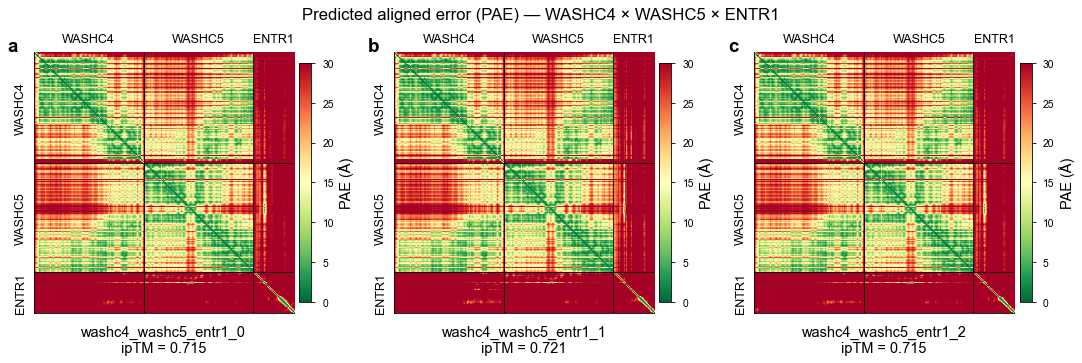

In [8]:
# ── Figure 1: PAE heatmaps, one panel per model ───────────────────────────────
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(NC2, NC2 / n_models),
                         constrained_layout=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    d  = models_data[model]
    pae, tc = d["pae"], d["tc"]
    N = len(tc)

    im = ax.imshow(pae, cmap="RdYlGn_r", vmin=0, vmax=30,
                   aspect="equal", interpolation="nearest", rasterized=True)

    bounds = chain_boundaries(tc)
    for b in bounds[1:-1]:
        ax.axhline(b - 0.5, color="k", linewidth=0.5, alpha=0.8)
        ax.axvline(b - 0.5, color="k", linewidth=0.5, alpha=0.8)

    unique_chains = list(dict.fromkeys(tc))
    offset = N * 0.05
    for k, c in enumerate(unique_chains):
        mid  = (bounds[k] + bounds[k + 1]) / 2
        name = CHAIN_GENE.get(c, c)
        ax.text(mid, -offset, name, ha="center", va="center",
                fontsize=6, rotation=0, clip_on=False)
        ax.text(-offset, mid, name, ha="center", va="center",
                fontsize=6, rotation=90, clip_on=False)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    iptm_str = f"{d['iptm_complex']:.3f}" if not np.isnan(d["iptm_complex"]) else "n/a"
    ax.set_xlabel(f"{model}\nipTM = {iptm_str}", labelpad=6)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, shrink=0.85)
    cb.set_label("PAE (Å)", labelpad=2)
    cb.ax.tick_params(labelsize=5, width=0.4, length=2)
    cb.outline.set_linewidth(0.4)

    ax.text(-0.1, 1.06, _panel_label(idx), transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

fig.suptitle("Predicted aligned error (PAE) — WASHC4 × WASHC5 × ENTR1", fontsize=8)
save_fig(fig, "pae_heatmaps_all_models")
plt.show()

**Fig. 1 | Predicted aligned error (PAE) heatmaps for the three assembled models of the WASHC4–WASHC5–ENTR1 complex.**
Each panel shows the full N×N PAE matrix (Å) for one assembled model (`washc4_washc5_entr1_0/1/2`). Rows/columns are residues ordered by chain (WASHC4, WASHC5, ENTR1); solid black lines mark chain boundaries. Colour scale: 0 (green, high confidence) to 30 Å (red). The whole-complex ipTM (interface-PAE-derived, cutoff 12 Å) is reported below each panel.

## Figure 2 — Per-residue pLDDT for all three models

Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\wash4_wash5_entr1_metrics\plddt_per_residue_all_models.svg


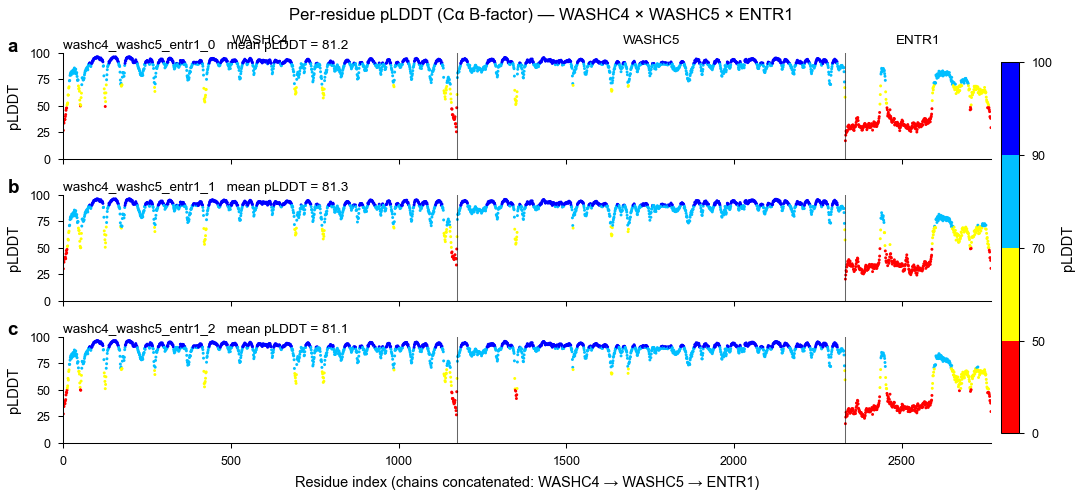

In [9]:
# ── Figure 2: per-residue pLDDT strip, one row per model ──────────────────────
fig, axes = plt.subplots(n_models, 1, figsize=(NC2, 1.1 * n_models),
                         constrained_layout=True, sharex=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    d  = models_data[model]
    plddt, chain_ids = d["plddt"], d["chain_ids"]
    x = np.arange(len(plddt))

    ax.scatter(x, plddt, c=plddt, cmap=PLDDT_CMAP, norm=PLDDT_NORM, s=2, linewidths=0)

    bounds = chain_boundaries(chain_ids)
    for b in bounds[1:-1]:
        ax.axvline(b, color="k", linewidth=0.5, alpha=0.6)

    if idx == 0:
        unique_chains = list(dict.fromkeys(chain_ids))
        for k, c in enumerate(unique_chains):
            mid = (bounds[k] + bounds[k + 1]) / 2
            ax.text(mid, 106, CHAIN_GENE.get(c, c), ha="center", va="bottom",
                    fontsize=6.5, clip_on=False)

    ax.set_ylim(0, 100)
    ax.set_xlim(0, len(plddt))
    ax.set_ylabel("pLDDT")
    ax.set_title(f"{model}   mean pLDDT = {d['mean_plddt']:.1f}", fontsize=6.5, loc="left", pad=2)
    ax.text(-0.06, 1.15, _panel_label(idx), transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

axes[-1].set_xlabel("Residue index (chains concatenated: WASHC4 → WASHC5 → ENTR1)")

cb = fig.colorbar(
    plt.cm.ScalarMappable(cmap=PLDDT_CMAP, norm=PLDDT_NORM),
    ax=axes, orientation="vertical", fraction=0.02, pad=0.01,
)
cb.set_label("pLDDT")

fig.suptitle("Per-residue pLDDT (Cα B-factor) — WASHC4 × WASHC5 × ENTR1", fontsize=8)
save_fig(fig, "plddt_per_residue_all_models")
plt.show()

**Fig. 2 | Per-residue predicted local distance difference test (pLDDT) for the three assembled models.**
Each row shows the Cα-atom pLDDT (from the PDB B-factor column) along the concatenated chain order WASHC4 → WASHC5 → ENTR1, coloured on the AlphaFold/ChimeraX scale (red < 50, yellow 50–70, sky-blue 70–90, blue > 90). Vertical black lines mark chain boundaries; the mean pLDDT is reported in each panel title.

## Figure 3 — Summary metrics across models

Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\wash4_wash5_entr1_metrics\metrics_summary_bar.svg


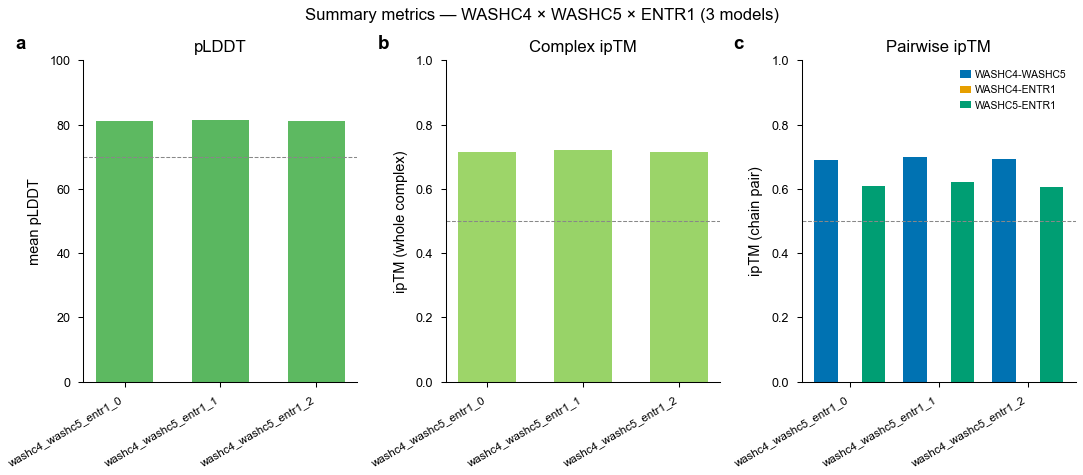

In [10]:
# ── Figure 3: summary bar chart (mean pLDDT, whole-complex ipTM, pairwise ipTM) ──
fig, axes = plt.subplots(1, 3, figsize=(NC2, NC1 * 0.9), constrained_layout=True)
x = np.arange(n_models)

# a: mean pLDDT
ax = axes[0]
vals = summary_df["mean_plddt"].values
ax.bar(x, vals, color=[plt.cm.RdYlGn(v / 100) for v in vals], width=0.6)
ax.axhline(70, color="#888888", linestyle="--", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha="right", fontsize=5.5)
ax.set_ylim(0, 100)
ax.set_ylabel("mean pLDDT")
ax.set_title("pLDDT", pad=4)
ax.text(-0.25, 1.08, "a", transform=ax.transAxes, fontsize=9, fontweight="bold", va="top")

# b: whole-complex ipTM
ax = axes[1]
vals = summary_df["iptm_complex"].fillna(0).values
ax.bar(x, vals, color=[plt.cm.RdYlGn(v) for v in vals], width=0.6)
ax.axhline(0.5, color="#888888", linestyle="--", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha="right", fontsize=5.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("ipTM (whole complex)")
ax.set_title("Complex ipTM", pad=4)
ax.text(-0.25, 1.08, "b", transform=ax.transAxes, fontsize=9, fontweight="bold", va="top")

# c: pairwise ipTM
ax = axes[2]
pair_cols = [c for c in summary_df.columns if c.startswith("iptm_") and c != "iptm_complex"]
width = 0.8 / len(pair_cols)
for i, col in enumerate(pair_cols):
    vals = summary_df[col].fillna(0).values
    ax.bar(x + i * width, vals, width=width, label=col.replace("iptm_", ""), color=WONG[i % len(WONG)])
ax.axhline(0.5, color="#888888", linestyle="--", linewidth=0.5)
ax.set_xticks(x + width); ax.set_xticklabels(MODELS, rotation=30, ha="right", fontsize=5.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("ipTM (chain pair)")
ax.set_title("Pairwise ipTM", pad=4)
ax.legend(loc="upper right", handlelength=1.0, handletextpad=0.4, fontsize=5)
ax.text(-0.25, 1.08, "c", transform=ax.transAxes, fontsize=9, fontweight="bold", va="top")

fig.suptitle("Summary metrics — WASHC4 × WASHC5 × ENTR1 (3 models)", fontsize=8)
save_fig(fig, "metrics_summary_bar")
plt.show()

**Fig. 3 | Summary confidence metrics across the three assembled models.**
**(a)** Mean per-residue pLDDT. **(b)** Whole-complex ipTM (interface-PAE-derived, cutoff 12 Å). **(c)** Pairwise ipTM computed after restricting the PAE matrix to each chain pair (WASHC4–WASHC5, WASHC4–ENTR1, WASHC5–ENTR1), isolating the confidence of each individual interface. Dashed reference lines mark pLDDT = 70 and ipTM = 0.5.

## Export

In [11]:
# ── Export summary table and per-residue pLDDT ────────────────────────────────
summary_csv = OUT_DIR / "wash4_wash5_entr1_metrics_summary.csv"
summary_df.to_csv(summary_csv, index=False)

residue_rows = []
for model, d in models_data.items():
    for chain, res_id, plddt in zip(d["chain_ids"], d["res_ids"], d["plddt"]):
        residue_rows.append({
            "model" : model,
            "chain" : chain,
            "gene"  : CHAIN_GENE.get(chain, chain),
            "res_id": int(res_id),
            "plddt" : round(float(plddt), 2),
        })
residue_df = pd.DataFrame(residue_rows)
residue_csv = OUT_DIR / "wash4_wash5_entr1_per_residue_plddt.csv"
residue_df.to_csv(residue_csv, index=False)

print(f"Saved summary     → {summary_csv}")
print(f"Saved per-residue → {residue_csv}")
print(f"Saved SVG figures → {FIGURE_DIR}")
print()
print(summary_df.to_string(index=False))

Saved summary     → N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\assembled_complex\metrics_wash4_wash5_entr1\wash4_wash5_entr1_metrics_summary.csv
Saved per-residue → N:\08_NK_structure_prediction\data\WASH_complex\wash4_wash5_entr1_jurkat\assembled_complex\metrics_wash4_wash5_entr1\wash4_wash5_entr1_per_residue_plddt.csv
Saved SVG figures → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\wash4_wash5_entr1_metrics

                model  n_residues  mean_plddt  iptm_complex  mean_inter_pae  iptm_WASHC4-WASHC5  iptm_WASHC4-ENTR1  iptm_WASHC5-ENTR1
washc4_washc5_entr1_0        2767       81.21        0.7146           23.47              0.6910                NaN             0.6102
washc4_washc5_entr1_1        2767       81.26        0.7212           23.50              0.6981                NaN             0.6216
washc4_washc5_entr1_2        2767       81.06        0.7150           23.49              0.6915                NaN             0.606

## PyMOL export — WASHC5×ENTR1 PAE interface (PAE < 10 Å highlighted)

For each model, WASHC5 (chain E) is coloured **light blue** overall, with residues
that have an inter-chain PAE below 10 Å to at least one ENTR1 residue coloured
**dark blue**. ENTR1 (chain F) is coloured **light red** overall, with its PAE<10
residues coloured **dark red**. WASHC4 (chain D) stays neutral grey for context.
Scripts are written as `.pml` files that load the PDB via a relative filename, so
the PDB copies must sit alongside the scripts in the same folder.

In [ ]:
# ── PyMOL export: WASHC5 x ENTR1 PAE interface (PAE < 10 A highlighted) ──────
import shutil

PAE_INTERFACE_CUTOFF = 10.0
PML_OUT_DIR = Path(r"C:\Users\zhang.zehong\Desktop\xl_distance_annotation")
PML_OUT_DIR.mkdir(parents=True, exist_ok=True)


def interface_residues(tc, tr, pae, chain_a, chain_b, cutoff=PAE_INTERFACE_CUTOFF):
    # Residues of chain_a / chain_b with inter-chain PAE < cutoff to the partner chain.
    mask_a = tc == chain_a
    mask_b = tc == chain_b
    sub_ab = pae[np.ix_(mask_a, mask_b)]
    sub_ba = pae[np.ix_(mask_b, mask_a)]
    close = (sub_ab < cutoff) | (sub_ba.T < cutoff)
    res_a = set(tr[mask_a][close.any(axis=1)].tolist())
    res_b = set(tr[mask_b][close.any(axis=0)].tolist())
    return res_a, res_b


def resi_string(residues):
    return "+".join(str(r) for r in sorted(residues))


for model in MODELS:
    d = models_data[model]
    tc, tr, pae = d["tc"], d["tr"], d["pae"]

    washc5_hot, entr1_hot = interface_residues(tc, tr, pae, "E", "F")
    all_washc5 = set(tr[tc == "E"].tolist())
    all_entr1  = set(tr[tc == "F"].tolist())

    pdb_src  = PDB_ROOT / model / f"{model}.pdb"
    pdb_name = f"{model}.pdb"
    shutil.copyfile(pdb_src, PML_OUT_DIR / pdb_name)

    lines = [
        f"load {pdb_name}, {model}",
        "hide everything",
        "show cartoon",
        "set_color washc5_light, [0.68, 0.85, 0.95]",
        "set_color washc5_dark,  [0.00, 0.20, 0.80]",
        "set_color entr1_light,  [1.00, 0.75, 0.75]",
        "set_color entr1_dark,   [0.75, 0.00, 0.00]",
        "color grey80, chain D",
        "color washc5_light, chain E",
        "color entr1_light, chain F",
    ]
    if washc5_hot:
        lines.append(f"color washc5_dark, chain E and resi {resi_string(washc5_hot)}")
    if entr1_hot:
        lines.append(f"color entr1_dark, chain F and resi {resi_string(entr1_hot)}")
    lines += [
        "bg_color white",
        "set ray_opaque_background, 0",
        "zoom",
    ]

    pml_path = PML_OUT_DIR / f"{model}_wash5_entr1_pae_interface.pml"
    with open(pml_path, "w", newline="\n") as f:
        f.write("\n".join(lines) + "\n")

    print(f"{model}: WASHC5 hot {len(washc5_hot)}/{len(all_washc5)}  "
          f"ENTR1 hot {len(entr1_hot)}/{len(all_entr1)}  -> {pml_path}")

## Figure — PAE<10 interface regions boxed, with sequence boundaries

For each model, contiguous stretches of PAE<10 residues (the same residues
coloured dark blue/dark red in the PyMOL scripts above) are grouped into
segments. Each segment is framed with a black box on the diagonal of the PAE
heatmap, and the segment's first/last residue (number + one-letter amino
acid) is printed below.

In [ ]:
# ── Box PAE<10 interface segments on the PAE heatmap and report their bounds ──
AA3TO1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}


def get_residue_names(pdb_path):
    # Return {(chain, resid): one-letter amino acid} from a PDB file.
    structure = _pdb_parser.get_structure("s", str(pdb_path))
    names = {}
    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] != " " or "CA" not in res:
                    continue
                names[(chain.id, res.id[1])] = AA3TO1.get(res.resname, "X")
        break
    return names


def contiguous_segments(residues):
    # Group residue numbers into sorted contiguous (start, end) ranges.
    residues = sorted(residues)
    segments = []
    for r in residues:
        if segments and r == segments[-1][1] + 1:
            segments[-1] = (segments[-1][0], r)
        else:
            segments.append((r, r))
    return segments


fig, axes = plt.subplots(1, len(MODELS), figsize=(NC2, NC2 / len(MODELS)), constrained_layout=True)

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    d = models_data[model]
    tc, tr, pae = d["tc"], d["tr"], d["pae"]

    washc5_hot, entr1_hot = interface_residues(tc, tr, pae, "E", "F")
    seg_e = contiguous_segments(washc5_hot)
    seg_f = contiguous_segments(entr1_hot)

    aa = get_residue_names(PDB_ROOT / model / f"{model}.pdb")
    offset_e = int(np.where(tc == "E")[0][0])
    offset_f = int(np.where(tc == "F")[0][0])

    im = ax.imshow(pae, cmap="RdYlGn_r", vmin=0, vmax=30,
                   aspect="equal", interpolation="nearest", rasterized=True)

    bounds = chain_boundaries(tc)
    for b in bounds[1:-1]:
        ax.axhline(b - 0.5, color="k", linewidth=0.5, alpha=0.8)
        ax.axvline(b - 0.5, color="k", linewidth=0.5, alpha=0.8)

    print(f"\n=== {model} ===")
    print("WASHC5 (chain E) PAE<10 segments:")
    for start, end in seg_e:
        row0, row1 = offset_e + start - 1, offset_e + end
        ax.add_patch(plt.Rectangle((row0 - 0.5, row0 - 0.5), row1 - row0, row1 - row0,
                                    fill=False, edgecolor="black", linewidth=1.0))
        print(f"  {start}-{end}  {aa.get(('E', start), 'X')}{start} ... {aa.get(('E', end), 'X')}{end}")

    print("ENTR1 (chain F) PAE<10 segments:")
    for start, end in seg_f:
        col0, col1 = offset_f + start - 1, offset_f + end
        ax.add_patch(plt.Rectangle((col0 - 0.5, col0 - 0.5), col1 - col0, col1 - col0,
                                    fill=False, edgecolor="black", linewidth=1.0))
        print(f"  {start}-{end}  {aa.get(('F', start), 'X')}{start} ... {aa.get(('F', end), 'X')}{end}")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(model, fontsize=6.5)

fig.suptitle("PAE<10 interface segments (boxed) — WASHC4 × WASHC5 × ENTR1", fontsize=8)
save_fig(fig, "pae_interface_regions_boxed")
plt.show()